To push into github

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from matplotlib import colors
import pickle
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.stats import chi2_contingency
from statsmodels.tools.eval_measures import aic, bic
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
from statsmodels.stats.stattools import durbin_watson

In [3]:
warnings.filterwarnings("ignore")

In [5]:
file_path = Path('ESS10.csv')

In [7]:
df = pd.read_csv(file_path, sep=',', low_memory=False)

In [9]:
df.head()

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,vinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS10e03_2,10,3.2,02.11.2023,10038,BE,0.882220,0.972276,0.718075,0.698167,...,2022-09-01 17:47:00,2022-09-01 17:47:00,2022-09-01 17:47:00,2022-09-01 17:47:00,36.0,1,1.0,0.000397,188,2596
1,ESS10e03_2,10,3.2,02.11.2023,10053,BE,1.047643,0.888635,0.718075,0.638107,...,2022-04-08 11:07:00,2022-04-08 11:10:00,2022-04-08 11:07:00,2022-04-08 11:10:00,54.0,2,2.0,0.000334,194,2206
2,ESS10e03_2,10,3.2,02.11.2023,10055,BE,1.087741,0.722811,0.718075,0.519033,...,2022-05-20 11:08:00,2022-05-20 11:10:00,2022-05-20 11:08:00,2022-05-20 11:10:00,77.0,1,2.0,0.000322,198,2114
3,ESS10e03_2,10,3.2,02.11.2023,10062,BE,0.909910,1.005565,0.718075,0.722072,...,2022-05-22 13:58:00,2022-05-22 13:59:00,2022-05-22 13:58:00,2022-05-22 13:59:00,55.0,1,1.0,0.000385,150,2645
4,ESS10e03_2,10,3.2,02.11.2023,10064,BE,0.918949,0.638705,0.718075,0.458639,...,2022-05-18 11:44:00,2022-05-18 11:45:00,2022-05-18 11:44:00,2022-05-18 11:45:00,55.0,1,1.0,0.000381,149,2313


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37611 entries, 0 to 37610
Columns: 618 entries, name to psu
dtypes: float64(209), int64(385), object(24)
memory usage: 177.3+ MB


In [13]:
columns_list = df.columns.to_list()

In [54]:
# '''
# vdcond - Interview conducted, how
# respc19 - Respondent had COVID-19
# cntry - Country
# netusoft - Internet use, how often
# polintr - How interested in politics
# actrolga - Able to take active role in political group
# cptppola - Confident in own ability to participate in politics
# pstplonl - Posted or shared anything about politics online last 12 months
# volunfp - Volunteered for not-for-profit or charitable organisation
# stflife - How satisfied with life as a whole
# stfeco - How satisfied with present state of economy in country
# stfgov - How satisfied with the national government
# happy - How happy are you
# sclact - Take part in social activities compared to others of same age
# crmvct - Respondent or household member victim of burglary/assault last 5 years
# health - Subjective general health
# hlthhmp - Hampered in daily activities by illness/disability/infirmity/mental problem
# rlgblg - Belonging to particular religion or denomination
# rlgdgr - How religious are you
# ctzcntr - Citizen of country
# cntbrthd - Country of birth
# vteurmmb - Would vote for [country] to remain member of European Union or leave
# votedir - Citizens have the final say on political issues by voting directly in referendums
# hhmmb - Number of people living regularly as member of household
# gndr - Gender
# gndr2 - Gender of second person in household
# yrbrn - Year of birth
# agea - Age of respondent, calculated
# yrbrn2 - Year of birth of second person in household
# rshipa2 - Second person in household: relationship to respondent
# rshpsts - Relationship with husband/wife/partner currently living with
# dvrcdeva - Ever been divorced/had civil union dissolved
# marsts - Legal marital status
# edulvlb - Highest level of education
# eisced - Highest level of education, ES - ISCED
# eduyrs - Years of full-time education completed
# pdwrk - Doing last 7 days: paid work
# edctn - Doing last 7 days: education
# uempla - Doing last 7 days: unemployed, actively looking for job
# dsbld - Doing last 7 days: permanently sick or disabled
# rtrd - Doing last 7 days: retired
# pdjobev - Ever had a paid job
# cmsrv - Doing last 7 days: community or military service
# pdjobyr - Year last in paid job
# emplrel - Employment relation
# wkhct - Total contracted hours per week in main job overtime excluded
# wkhtot - Total hours normally worked per week in main job overtime included
# tporgwk - What type of organisation work/worked for
# uemp5yr - Any period of unemployment and work seeking within last 5 years
# hincsrca - Main source of household income
# edulvlpb - Partner's highest level of education
# wkhtotp - Hours normally worked a week in main job overtime included, partner
# edulvlfb - Father's highest level of education
# region - Region
# atncrse - Improve knowledge/skills: course/lecture/conference, last 12 months
# acchome - Location able to access the internet: Home
# accwrk - Location able to access the internet: Workplace
# accmove - Location able to access the internet: On the move
# fampdf - PDF, how familiar
# chldo12 - Number of children aged 12 or over
# hhlipnt - Parent lives in same household
# livpnt - Parents still alive
# agepnt - Age of parent
# closepnt - How close to parent
# ttminpnt - Travel time to parent, in minutes
# speakpnt - Speak with parent in person, how often
# stfmjob - How satisfied are you in your main job
# trdawrk - Too tired after work to enjoy things like doing at home, how often
# jbprtfp - Job prevents you from giving time to partner/family, how often
# pfmfdjba - Partner/family fed up with pressure of your job, how often
# dcsfwrka - Current job: can decide time start/finish work
# wrkhome - Work from home or place of choice, how often
# mansupp - Line manager supports employees in balancing work, how much
# manhlp - Line manager gives work-related help, how likely
# teamfeel - Feel like part of your team, how much
# wrkextra - Take on extra responsibilities at work without being paid more
# colprop - Proportion of colleagues based at the same location
# colhlp - Colleagues give work-related help, how likely
# ipcrtiv - Important to think new ideas and being creative
# imprich - Important to be rich, have money and expensive things
# ipeqopt - Important that people are treated equally and have equal opportunities
# impdiff - Important to try new and different things in life
# ipfrule - Important to do what is told and follow rules
# ipgdtim - Important to have a good time
# impfree - Important to make own decisions and be free
# '''

🧍 Demographics
agea – Age of respondent

gndr – Gender

yrbrn – Year of birth

marsts – Legal marital status

domicil – Domicile, respondent's description

🎓 Education
edulvlb – Highest level of education

eisced – ISCED level of education

eduyrs – Years of education

edagegb – Age finished education (UK-specific)

edulvlpb – Partner’s education level

💰 Economic Status
hincfel – Feelings about household income

hinctnta – Household total net income

hincsrca – Main source of household income

🩺 Health
health – Subjective general health

hlthhmp – Hampered in daily activities

🌐 Internet/Social
netusoft – Internet use frequency

netustm – Internet use time

sclmeet – Social meetings frequency

sclact – Social activity compared to others

inprdsc – People to discuss intimate matters

🗳️ Political Trust / Civic Engagement
trstprl – Trust in parliament

trstlgl – Trust in legal system

trstplc – Trust in police

vote – Voted last election

contplt – Contacted politician

🧠 Attitudes and Values
ppltrst – Trust in people

pplhlp – Belief others are helpful

stflife – Life satisfaction

happy – Happiness

ipcrtiv – Importance of creativity

📦 Discrimination & Identity
dscrgrp – Member of discriminated group

dscrgnd – Discrimination by gender

brncntr – Born in country

ctzcntr – Citizen of country

feethngr – Feels same race/ethnicity as others

👨‍👩‍👧 Household and Family
hhmmb – Number of household members

chldhhe – Ever had children in household

rshipa2 – Relationship of 2nd person in household

pdwrkp – Partner in paid work

mnactp – Partner’s main activity

💼 Job Characteristics (for those who have worked)
wrkctra – Type of work contract

emplrel – Employment relation

estsz – Establishment size

jbspv – Supervise others

wkhtot – Hours worked per week

🧩 Miscellaneous
imsmetn – Immigration same ethnicity

imdfetn – Immigration different ethnicity

euftf – View on EU unification

loylead – Country needs loyalty to leaders

ipmodst – Importance of modesty

In [15]:
employed_conditions = (df['pdwrk'] == 1)

# Define unemployed conditions (actively or passively unemployed, retired, disabled, housework, other)
unemployed_conditions = (
    (df['uempla'] == 1) | 
    (df['uempli'] == 1) | 
    (df['rtrd'] == 1) | 
    (df['dsbld'] == 1) | 
    (df['hswrk'] == 1) | 
    (df['dngoth'] == 1)
)

# Create employment_status column: 1 for employed, 0 for unemployed
df['employment_status'] = None  # Initialize
df.loc[employed_conditions, 'employment_status'] = 1
df.loc[unemployed_conditions, 'employment_status'] = 0

# Optionally convert to integer type if all values are filled
df['employment_status'] = df['employment_status'].astype('Int64')  # Keeps NA if any

# Optional: print value counts to check distribution
print(df['employment_status'].value_counts(dropna=False))

employment_status
1       18135
0       17250
<NA>     2226
Name: count, dtype: Int64


In [17]:
df_copy = df.copy()

In [19]:
columns = [
    "employment_status","agea", "gndr", "yrbrn", "marsts", "domicil", "edulvlb", "eisced", "eduyrs", "edagegb", "edulvlpb",
    "hincfel", "hinctnta", "hincsrca", "health", "hlthhmp", "netusoft", "netustm", "sclmeet", "sclact", "inprdsc",
    "trstprl", "trstlgl", "trstplc", "vote", "contplt", "ppltrst", "pplhlp", "stflife", "happy", "ipcrtiv",
    "dscrgrp", "dscrgnd", "brncntr", "ctzcntr", "feethngr", "hhmmb", "chldhhe", "rshipa2", "pdwrkp", "mnactp",
    "wrkctra", "emplrel", "estsz", "jbspv", "wkhtot", "imsmetn", "imdfetn", "euftf", "loylead", "ipmodst"
]

df = df[columns].copy()


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37611 entries, 0 to 37610
Data columns (total 51 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employment_status  35385 non-null  Int64  
 1   agea               37611 non-null  int64  
 2   gndr               37611 non-null  int64  
 3   yrbrn              37611 non-null  int64  
 4   marsts             37611 non-null  int64  
 5   domicil            37611 non-null  int64  
 6   edulvlb            37611 non-null  int64  
 7   eisced             37611 non-null  int64  
 8   eduyrs             37611 non-null  int64  
 9   edagegb            1149 non-null   float64
 10  edulvlpb           34812 non-null  float64
 11  hincfel            37611 non-null  int64  
 12  hinctnta           37611 non-null  int64  
 13  hincsrca           37611 non-null  int64  
 14  health             37611 non-null  int64  
 15  hlthhmp            37611 non-null  int64  
 16  netusoft           376

In [31]:
import pandas as pd

# Assuming you have already loaded your dataset as `df`
# Example: df = pd.read_csv("your_ess_cleaned_data.csv")

# List of your selected 50 variables
selected_vars = [
    'agea', 'gndr', 'yrbrn', 'marsts', 'domicil',
    'edulvlb', 'eisced', 'eduyrs', 'edagegb', 'edulvlpb',
    'hincfel', 'hinctnta', 'hincsrca',
    'health', 'hlthhmp',
    'netusoft', 'netustm', 'sclmeet', 'sclact', 'inprdsc',
    'trstprl', 'trstlgl', 'trstplc', 'vote', 'contplt',
    'ppltrst', 'pplhlp', 'stflife', 'happy', 'ipcrtiv',
    'dscrgrp', 'dscrgnd', 'brncntr', 'ctzcntr', 'feethngr',
    'hhmmb', 'chldhhe', 'rshipa2', 'pdwrkp', 'mnactp',
    'wrkctra', 'emplrel', 'estsz', 'jbspv', 'wkhtot',
    'imsmetn', 'imdfetn', 'euftf', 'loylead', 'ipmodst'
]

# Filter the dataframe to include only these variables
df_selected = df[selected_vars]

# Show summary statistics (count, mean, std, min, max, etc.)
summary_table = df_selected.describe(include='all').T
summary_table


,count,mean,std,min,25%,50%,75%,max
agea,37611.0,58.212331,85.216511,15.0,36.0,52.0,66.0,999.0
gndr,37611.0,1.535694,0.498731,1.0,1.0,2.0,2.0,2.0
yrbrn,37611.0,2019.037542,554.088138,1931.0,1956.0,1970.0,1985.0,9999.0
marsts,37611.0,33.947914,30.564956,1.0,6.0,6.0,66.0,99.0
domicil,37611.0,2.875169,1.228797,1.0,2.0,3.0,4.0,9.0
edulvlb,37611.0,444.053601,617.080158,0.0,313.0,323.0,610.0,9999.0
eisced,37611.0,4.598947,6.069719,1.0,3.0,4.0,6.0,99.0
eduyrs,37611.0,14.324081,10.319706,0.0,11.0,13.0,16.0,99.0
edagegb,1149.0,57.461271,555.978188,1.0,16.0,18.0,21.0,8888.0
edulvlpb,34812.0,3213.214552,3184.836988,0.0,322.0,720.0,6666.0,9999.0


In [23]:
df.head()

,employment_status,agea,gndr,yrbrn,marsts,domicil,edulvlb,eisced,eduyrs,edagegb,...,wrkctra,emplrel,estsz,jbspv,wkhtot,imsmetn,imdfetn,euftf,loylead,ipmodst
0,<NA>,16,2,2006,6,4,113,1,11,NaN,...,6,6,6,6,666,2,2,5,2,3
1,0,24,2,1998,6,4,720,7,18,NaN,...,2,1,3,1,40,1,1,5,8,5
2,0,58,1,1964,66,4,610,6,18,NaN,...,2,1,2,1,42,1,2,8,3,3
3,1,35,1,1987,4,1,323,4,12,NaN,...,1,1,4,2,35,1,1,88,8,2
4,1,61,1,1961,6,2,800,7,19,NaN,...,1,1,5,1,40,2,2,9,4,3


In [294]:
columns_with_missings = df.columns[df.isnull().any()]

In [296]:
df[columns_with_missings].isnull().any()

employment_status    True
edagegb              True
edulvlpb             True
dtype: bool

In [298]:
df[columns_with_missings].isnull().sum()

employment_status     2226
edagegb              36462
edulvlpb              2799
dtype: int64

In [300]:
# frequency tables for these columns
print('Frequency counts for employment_status')
print(df.employment_status.value_counts(dropna=False))

Frequency counts for employment_status
employment_status
1       18135
0       17250
<NA>     2226
Name: count, dtype: Int64


In [302]:
print('Frequency counts for edagegb')
print(df.edagegb.value_counts(dropna = False))

Frequency counts for edagegb
edagegb
NaN       36462
16.0        257
15.0        167
18.0        129
21.0        125
17.0         96
22.0         89
19.0         49
23.0         43
20.0         35
24.0         30
96.0         22
14.0         19
25.0         18
27.0         12
95.0         10
26.0         10
28.0          7
8888.0        3
13.0          3
11.0          2
7777.0        2
30.0          2
12.0          2
33.0          2
62.0          1
50.0          1
49.0          1
48.0          1
10.0          1
47.0          1
31.0          1
29.0          1
37.0          1
8.0           1
52.0          1
51.0          1
32.0          1
35.0          1
1.0           1
Name: count, dtype: int64


In [304]:
print('Frequency counts for edulvlpb')
print(df.edulvlpb.value_counts(dropna=False))

Frequency counts for edulvlpb
edulvlpb
6666.0    14663
323.0      3074
NaN        2799
321.0      2538
720.0      2342
313.0      2126
213.0      1832
620.0      1320
113.0      1062
610.0      1022
520.0       962
423.0       536
710.0       498
322.0       486
421.0       468
9999.0      362
229.0       278
800.0       234
222.0       173
8888.0      150
212.0       138
7777.0      134
0.0         122
510.0        86
422.0        45
312.0        42
223.0        37
5555.0       28
221.0        27
413.0        12
412.0        12
129.0         3
Name: count, dtype: int64


In [306]:
df.employment_status.fillna(0, inplace=True)

In [308]:
df.drop(['edagegb'], axis=1, inplace=True)

In [310]:
df.edulvlpb.fillna(6666, inplace=True)

In [312]:
print('Frequency counts for employment_status')
print(df.employment_status.value_counts(dropna=False))

Frequency counts for employment_status
employment_status
0    19476
1    18135
Name: count, dtype: Int64


In [314]:
print('Frequency counts for edulvlpb')
print(df.edulvlpb.value_counts(dropna=False))

Frequency counts for edulvlpb
edulvlpb
6666.0    17462
323.0      3074
321.0      2538
720.0      2342
313.0      2126
213.0      1832
620.0      1320
113.0      1062
610.0      1022
520.0       962
423.0       536
710.0       498
322.0       486
421.0       468
9999.0      362
229.0       278
800.0       234
222.0       173
8888.0      150
212.0       138
7777.0      134
0.0         122
510.0        86
422.0        45
312.0        42
223.0        37
5555.0       28
221.0        27
413.0        12
412.0        12
129.0         3
Name: count, dtype: int64


In [316]:
columns_with_missings = df.columns[df.isnull().any()]

In [318]:
df[columns_with_missings].isnull().sum()

Series([], dtype: float64)

In [320]:
df[columns_with_missings].isnull().any()

Series([], dtype: bool)

In [322]:
df.isna().sum()

employment_status    0
agea                 0
gndr                 0
yrbrn                0
marsts               0
domicil              0
edulvlb              0
eisced               0
eduyrs               0
edulvlpb             0
hincfel              0
hinctnta             0
hincsrca             0
health               0
hlthhmp              0
netusoft             0
netustm              0
sclmeet              0
sclact               0
inprdsc              0
trstprl              0
trstlgl              0
trstplc              0
vote                 0
contplt              0
ppltrst              0
pplhlp               0
stflife              0
happy                0
ipcrtiv              0
dscrgrp              0
dscrgnd              0
brncntr              0
ctzcntr              0
feethngr             0
hhmmb                0
chldhhe              0
rshipa2              0
pdwrkp               0
mnactp               0
wrkctra              0
emplrel              0
estsz                0
jbspv      

In [324]:
df.columns

Index(['employment_status', 'agea', 'gndr', 'yrbrn', 'marsts', 'domicil',
       'edulvlb', 'eisced', 'eduyrs', 'edulvlpb', 'hincfel', 'hinctnta',
       'hincsrca', 'health', 'hlthhmp', 'netusoft', 'netustm', 'sclmeet',
       'sclact', 'inprdsc', 'trstprl', 'trstlgl', 'trstplc', 'vote', 'contplt',
       'ppltrst', 'pplhlp', 'stflife', 'happy', 'ipcrtiv', 'dscrgrp',
       'dscrgnd', 'brncntr', 'ctzcntr', 'feethngr', 'hhmmb', 'chldhhe',
       'rshipa2', 'pdwrkp', 'mnactp', 'wrkctra', 'emplrel', 'estsz', 'jbspv',
       'wkhtot', 'imsmetn', 'imdfetn', 'euftf', 'loylead', 'ipmodst'],
      dtype='object')

In [326]:
categorical_columns = df.select_dtypes('object').columns

In [328]:
categorical_columns

Index([], dtype='object')

In [330]:
numeric_variables = df.select_dtypes(include=[np.number]).columns

In [332]:
numeric_variables

Index(['employment_status', 'agea', 'gndr', 'yrbrn', 'marsts', 'domicil',
       'edulvlb', 'eisced', 'eduyrs', 'edulvlpb', 'hincfel', 'hinctnta',
       'hincsrca', 'health', 'hlthhmp', 'netusoft', 'netustm', 'sclmeet',
       'sclact', 'inprdsc', 'trstprl', 'trstlgl', 'trstplc', 'vote', 'contplt',
       'ppltrst', 'pplhlp', 'stflife', 'happy', 'ipcrtiv', 'dscrgrp',
       'dscrgnd', 'brncntr', 'ctzcntr', 'feethngr', 'hhmmb', 'chldhhe',
       'rshipa2', 'pdwrkp', 'mnactp', 'wrkctra', 'emplrel', 'estsz', 'jbspv',
       'wkhtot', 'imsmetn', 'imdfetn', 'euftf', 'loylead', 'ipmodst'],
      dtype='object')

## Near Zero Variance

In [334]:
def near_zero_variance(df, freq_cut = 95/5, unique_cut = 10):
    results = []
    for col in df.columns:
        counts = df[col].value_counts()
        if len(counts) > 1:
            freq_ratio = counts.iloc[0] / counts.iloc[1]
        else:
            freq_ratio = float('inf') # only one unique value

        # calculate unique_ratio
        unique_ratio = len(counts) / len(df)
        # determine binary indicators
        high_freq_ratio = int(freq_ratio > freq_cut)
        low_unique_ratio = int(unique_ratio < unique_cut)
        # append results
        results.append({
            'variable': col,
            'freq_ratio': freq_ratio,
            'unique_ratio': unique_ratio,
            'high_freq_ratio': high_freq_ratio,
            'low_unique_ratio': low_unique_ratio
        })
        # convert results to a DataFrame
        results_df = pd.DataFrame(results)
        # sort by 'high_freq_ratio' (descending) and 'low_unique_ratio' (ascending)
        results_df = results_df.sort_values(by=['freq_ratio', 'unique_ratio'], 
                                    ascending=[False, True])
        return results_df

In [336]:
df_nzv = near_zero_variance(df, freq_cut = 97/3, unique_cut = 5)
df_nzv[(df_nzv['low_unique_ratio']==1) & (df_nzv['high_freq_ratio']==1)]

,variable,freq_ratio,unique_ratio,high_freq_ratio,low_unique_ratio


In [338]:
for col in numeric_variables:
    print(f'Frequency table for {col}:')
    print(df[col].value_counts())

Frequency table for employment_status:
employment_status
0    19476
1    18135
Name: count, dtype: Int64
Frequency table for agea:
agea
61    728
56    715
60    687
58    687
51    687
     ... 
86    150
15     99
87     98
89     93
88     86
Name: count, Length: 77, dtype: int64
Frequency table for gndr:
gndr
2    20148
1    17463
Name: count, dtype: int64
Frequency table for yrbrn:
yrbrn
1960    788
1970    733
1965    721
1955    694
1980    690
       ... 
1933     85
1934     82
8888     54
9999     33
2007      3
Name: count, Length: 80, dtype: int64
Frequency table for marsts:
marsts
66    17417
6     11312
5      3436
4      3261
1       979
3       776
77      261
2       108
88       42
99       19
Name: count, dtype: int64
Frequency table for domicil:
domicil
4    12281
3    11351
1     8296
2     3968
5     1659
7       30
9       16
8       10
Name: count, dtype: int64
Frequency table for edulvlb:
edulvlb
323     5386
313     5304
213     4358
321     4078
720     3961


In [340]:
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=True, random_state=42)

In [342]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30088 entries, 6803 to 15795
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employment_status  30088 non-null  Int64  
 1   agea               30088 non-null  int64  
 2   gndr               30088 non-null  int64  
 3   yrbrn              30088 non-null  int64  
 4   marsts             30088 non-null  int64  
 5   domicil            30088 non-null  int64  
 6   edulvlb            30088 non-null  int64  
 7   eisced             30088 non-null  int64  
 8   eduyrs             30088 non-null  int64  
 9   edulvlpb           30088 non-null  float64
 10  hincfel            30088 non-null  int64  
 11  hinctnta           30088 non-null  int64  
 12  hincsrca           30088 non-null  int64  
 13  health             30088 non-null  int64  
 14  hlthhmp            30088 non-null  int64  
 15  netusoft           30088 non-null  int64  
 16  netustm            30088

In [344]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7523 entries, 22489 to 2278
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employment_status  7523 non-null   Int64  
 1   agea               7523 non-null   int64  
 2   gndr               7523 non-null   int64  
 3   yrbrn              7523 non-null   int64  
 4   marsts             7523 non-null   int64  
 5   domicil            7523 non-null   int64  
 6   edulvlb            7523 non-null   int64  
 7   eisced             7523 non-null   int64  
 8   eduyrs             7523 non-null   int64  
 9   edulvlpb           7523 non-null   float64
 10  hincfel            7523 non-null   int64  
 11  hinctnta           7523 non-null   int64  
 12  hincsrca           7523 non-null   int64  
 13  health             7523 non-null   int64  
 14  hlthhmp            7523 non-null   int64  
 15  netusoft           7523 non-null   int64  
 16  netustm            7523 n

<Axes: xlabel='employment_status', ylabel='Count'>

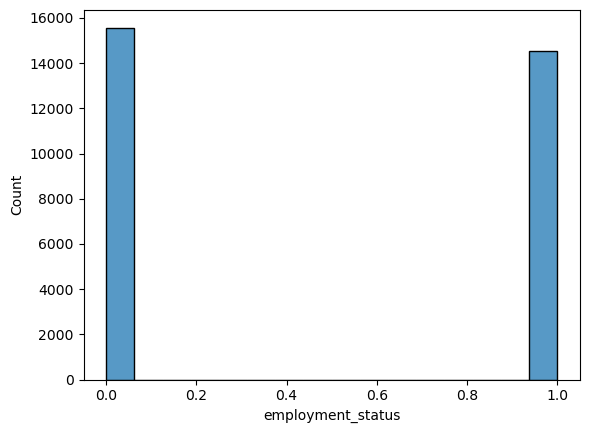

In [346]:
sns.histplot(df_train.employment_status)

In [348]:
df_train.employment_status.value_counts()

employment_status
0    15573
1    14515
Name: count, dtype: Int64

In [350]:
for col in numeric_variables:
    unique_vals = df_train[col].unique()
    n_unique = len(unique_vals)
    print(f'Column {col} has {n_unique} unique values')

    if n_unique <= 5:
        print(f'Frequency table for {col}:')
        print(df_train[col].value_counts(dropna=False), '\n')

Column employment_status has 2 unique values
Frequency table for employment_status:
employment_status
0    15573
1    14515
Name: count, dtype: Int64 

Column agea has 77 unique values
Column gndr has 2 unique values
Frequency table for gndr:
gndr
2    16048
1    14040
Name: count, dtype: int64 

Column yrbrn has 80 unique values
Column marsts has 10 unique values
Column domicil has 8 unique values
Column edulvlb has 30 unique values
Column eisced has 11 unique values
Column eduyrs has 47 unique values
Column edulvlpb has 31 unique values
Column hincfel has 7 unique values
Column hinctnta has 13 unique values
Column hincsrca has 11 unique values
Column health has 8 unique values
Column hlthhmp has 6 unique values
Column netusoft has 8 unique values
Column netustm has 204 unique values
Column sclmeet has 10 unique values
Column sclact has 8 unique values
Column inprdsc has 10 unique values
Column trstprl has 14 unique values
Column trstlgl has 14 unique values
Column trstplc has 14 uniq

In [352]:
df_train.head()

,employment_status,agea,gndr,yrbrn,marsts,domicil,edulvlb,eisced,eduyrs,edulvlpb,...,wrkctra,emplrel,estsz,jbspv,wkhtot,imsmetn,imdfetn,euftf,loylead,ipmodst
6803,1,34,1,1987,66,3,321,3,12,321.0,...,1,1,2,2,42,3,4,5,3,1
939,1,44,2,1978,66,4,213,2,13,421.0,...,1,1,3,2,29,2,3,0,3,2
3787,1,50,2,1971,66,1,313,4,11,421.0,...,2,1,4,2,40,2,3,7,2,3
19458,0,76,1,1945,5,3,321,3,12,6666.0,...,1,1,8,2,44,1,4,3,3,2
37067,1,66,2,1955,66,4,720,7,17,323.0,...,1,1,3,2,45,3,3,9,4,1


In [354]:
df_train.drop(['yrbrn'], axis=1, inplace=True)

In [356]:
df_test.drop(['yrbrn'], axis=1, inplace=True)

In [358]:
df_train.head()

,employment_status,agea,gndr,marsts,domicil,edulvlb,eisced,eduyrs,edulvlpb,hincfel,...,wrkctra,emplrel,estsz,jbspv,wkhtot,imsmetn,imdfetn,euftf,loylead,ipmodst
6803,1,34,1,66,3,321,3,12,321.0,2,...,1,1,2,2,42,3,4,5,3,1
939,1,44,2,66,4,213,2,13,421.0,2,...,1,1,3,2,29,2,3,0,3,2
3787,1,50,2,66,1,313,4,11,421.0,2,...,2,1,4,2,40,2,3,7,2,3
19458,0,76,1,5,3,321,3,12,6666.0,2,...,1,1,8,2,44,1,4,3,3,2
37067,1,66,2,66,4,720,7,17,323.0,2,...,1,1,3,2,45,3,3,9,4,1


In [360]:
numeric_columns = df_train.select_dtypes(include=[np.number]).columns

In [362]:
df_correlations = df_train[numeric_columns].corr(method='pearson')

In [364]:
df_correlations

,employment_status,agea,gndr,marsts,domicil,edulvlb,eisced,eduyrs,edulvlpb,hincfel,...,wrkctra,emplrel,estsz,jbspv,wkhtot,imsmetn,imdfetn,euftf,loylead,ipmodst
employment_status,1.000000,-0.066369,-0.095439,0.041956,-0.054742,0.053571,0.056560,0.073020,-0.104901,-0.157731,...,-0.212470,-0.319228,-0.235027,-0.285209,-0.253789,-0.047898,-0.056323,-0.070278,0.051899,0.048211
agea,-0.066369,1.000000,0.001846,0.044667,0.020598,0.073177,0.072482,0.046445,0.017297,0.050773,...,0.011121,-0.010058,0.022284,-0.007462,0.037584,0.047541,0.056373,0.027498,0.005249,-0.002157
gndr,-0.095439,0.001846,1.000000,-0.044666,-0.024905,-0.000037,0.000485,-0.014523,0.035972,0.050443,...,-0.016489,0.053496,0.039746,0.095259,0.034801,0.016566,0.010614,0.075464,0.007538,-0.039243
marsts,0.041956,0.044667,-0.044666,1.000000,0.060586,0.043497,0.041272,0.017269,-0.654287,-0.084093,...,-0.063687,-0.086209,-0.046318,-0.101833,-0.069368,0.012602,0.024619,-0.041755,-0.032290,-0.012314
domicil,-0.054742,0.020598,-0.024905,0.060586,1.000000,-0.026972,-0.029625,-0.042452,-0.075503,-0.000919,...,0.048184,0.038217,0.004795,0.034745,0.039545,0.041575,0.030618,0.027641,-0.055849,-0.067598
edulvlb,0.053571,0.073177,-0.000037,0.043497,-0.026972,1.000000,0.996831,0.300029,0.024061,0.012938,...,-0.003754,-0.002670,0.042026,-0.004831,0.016578,-0.012547,-0.032730,-0.009117,0.051656,0.058961
eisced,0.056560,0.072482,0.000485,0.041272,-0.029625,0.996831,1.000000,0.297736,0.028376,0.020150,...,-0.001618,-0.000235,0.039457,-0.000618,0.019406,-0.011183,-0.028946,-0.010712,0.052021,0.059464
eduyrs,0.073020,0.046445,-0.014523,0.017269,-0.042452,0.300029,0.297736,1.000000,0.014184,-0.022899,...,0.000235,-0.013932,0.057268,-0.015656,0.074951,-0.002766,-0.031302,-0.016239,0.062876,0.083298
edulvlpb,-0.104901,0.017297,0.035972,-0.654287,-0.075503,0.024061,0.028376,0.014184,1.000000,0.169745,...,0.162883,0.171330,0.061850,0.191144,0.153546,0.016246,0.048800,0.052986,0.065445,0.026329
hincfel,-0.157731,0.050773,0.050443,-0.084093,-0.000919,0.012938,0.020150,-0.022899,0.169745,1.000000,...,0.128138,0.157215,0.063605,0.197657,0.195054,0.146116,0.185974,0.112746,0.041464,0.046058


In [25]:

selected_vars = ['agea', 'gndr', 'eduyrs', 'edulvlb', 'hinctnta', 'health', 'hlthhmp', 
                 'netusoft', 'sclmeet', 'trstprl', 'dscrgrp', 'happy', 'wkhtot', 'emplrel']
df[selected_vars].describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
agea,37611.0,58.212331,85.216511,15.0,36.0,52.0,66.0,999.0
gndr,37611.0,1.535694,0.498731,1.0,1.0,2.0,2.0,2.0
eduyrs,37611.0,14.324081,10.319706,0.0,11.0,13.0,16.0,99.0
edulvlb,37611.0,444.053601,617.080158,0.0,313.0,323.0,610.0,9999.0
hinctnta,37611.0,21.763713,31.139742,1.0,4.0,7.0,10.0,99.0
health,37611.0,2.150382,0.935708,1.0,1.0,2.0,3.0,9.0
hlthhmp,37611.0,2.705884,0.654489,1.0,2.0,3.0,3.0,9.0
netusoft,37611.0,4.070697,1.500607,1.0,3.0,5.0,5.0,9.0
sclmeet,37611.0,4.972694,5.311766,1.0,4.0,5.0,6.0,99.0
trstprl,37611.0,6.049081,11.569210,0.0,2.0,5.0,7.0,99.0


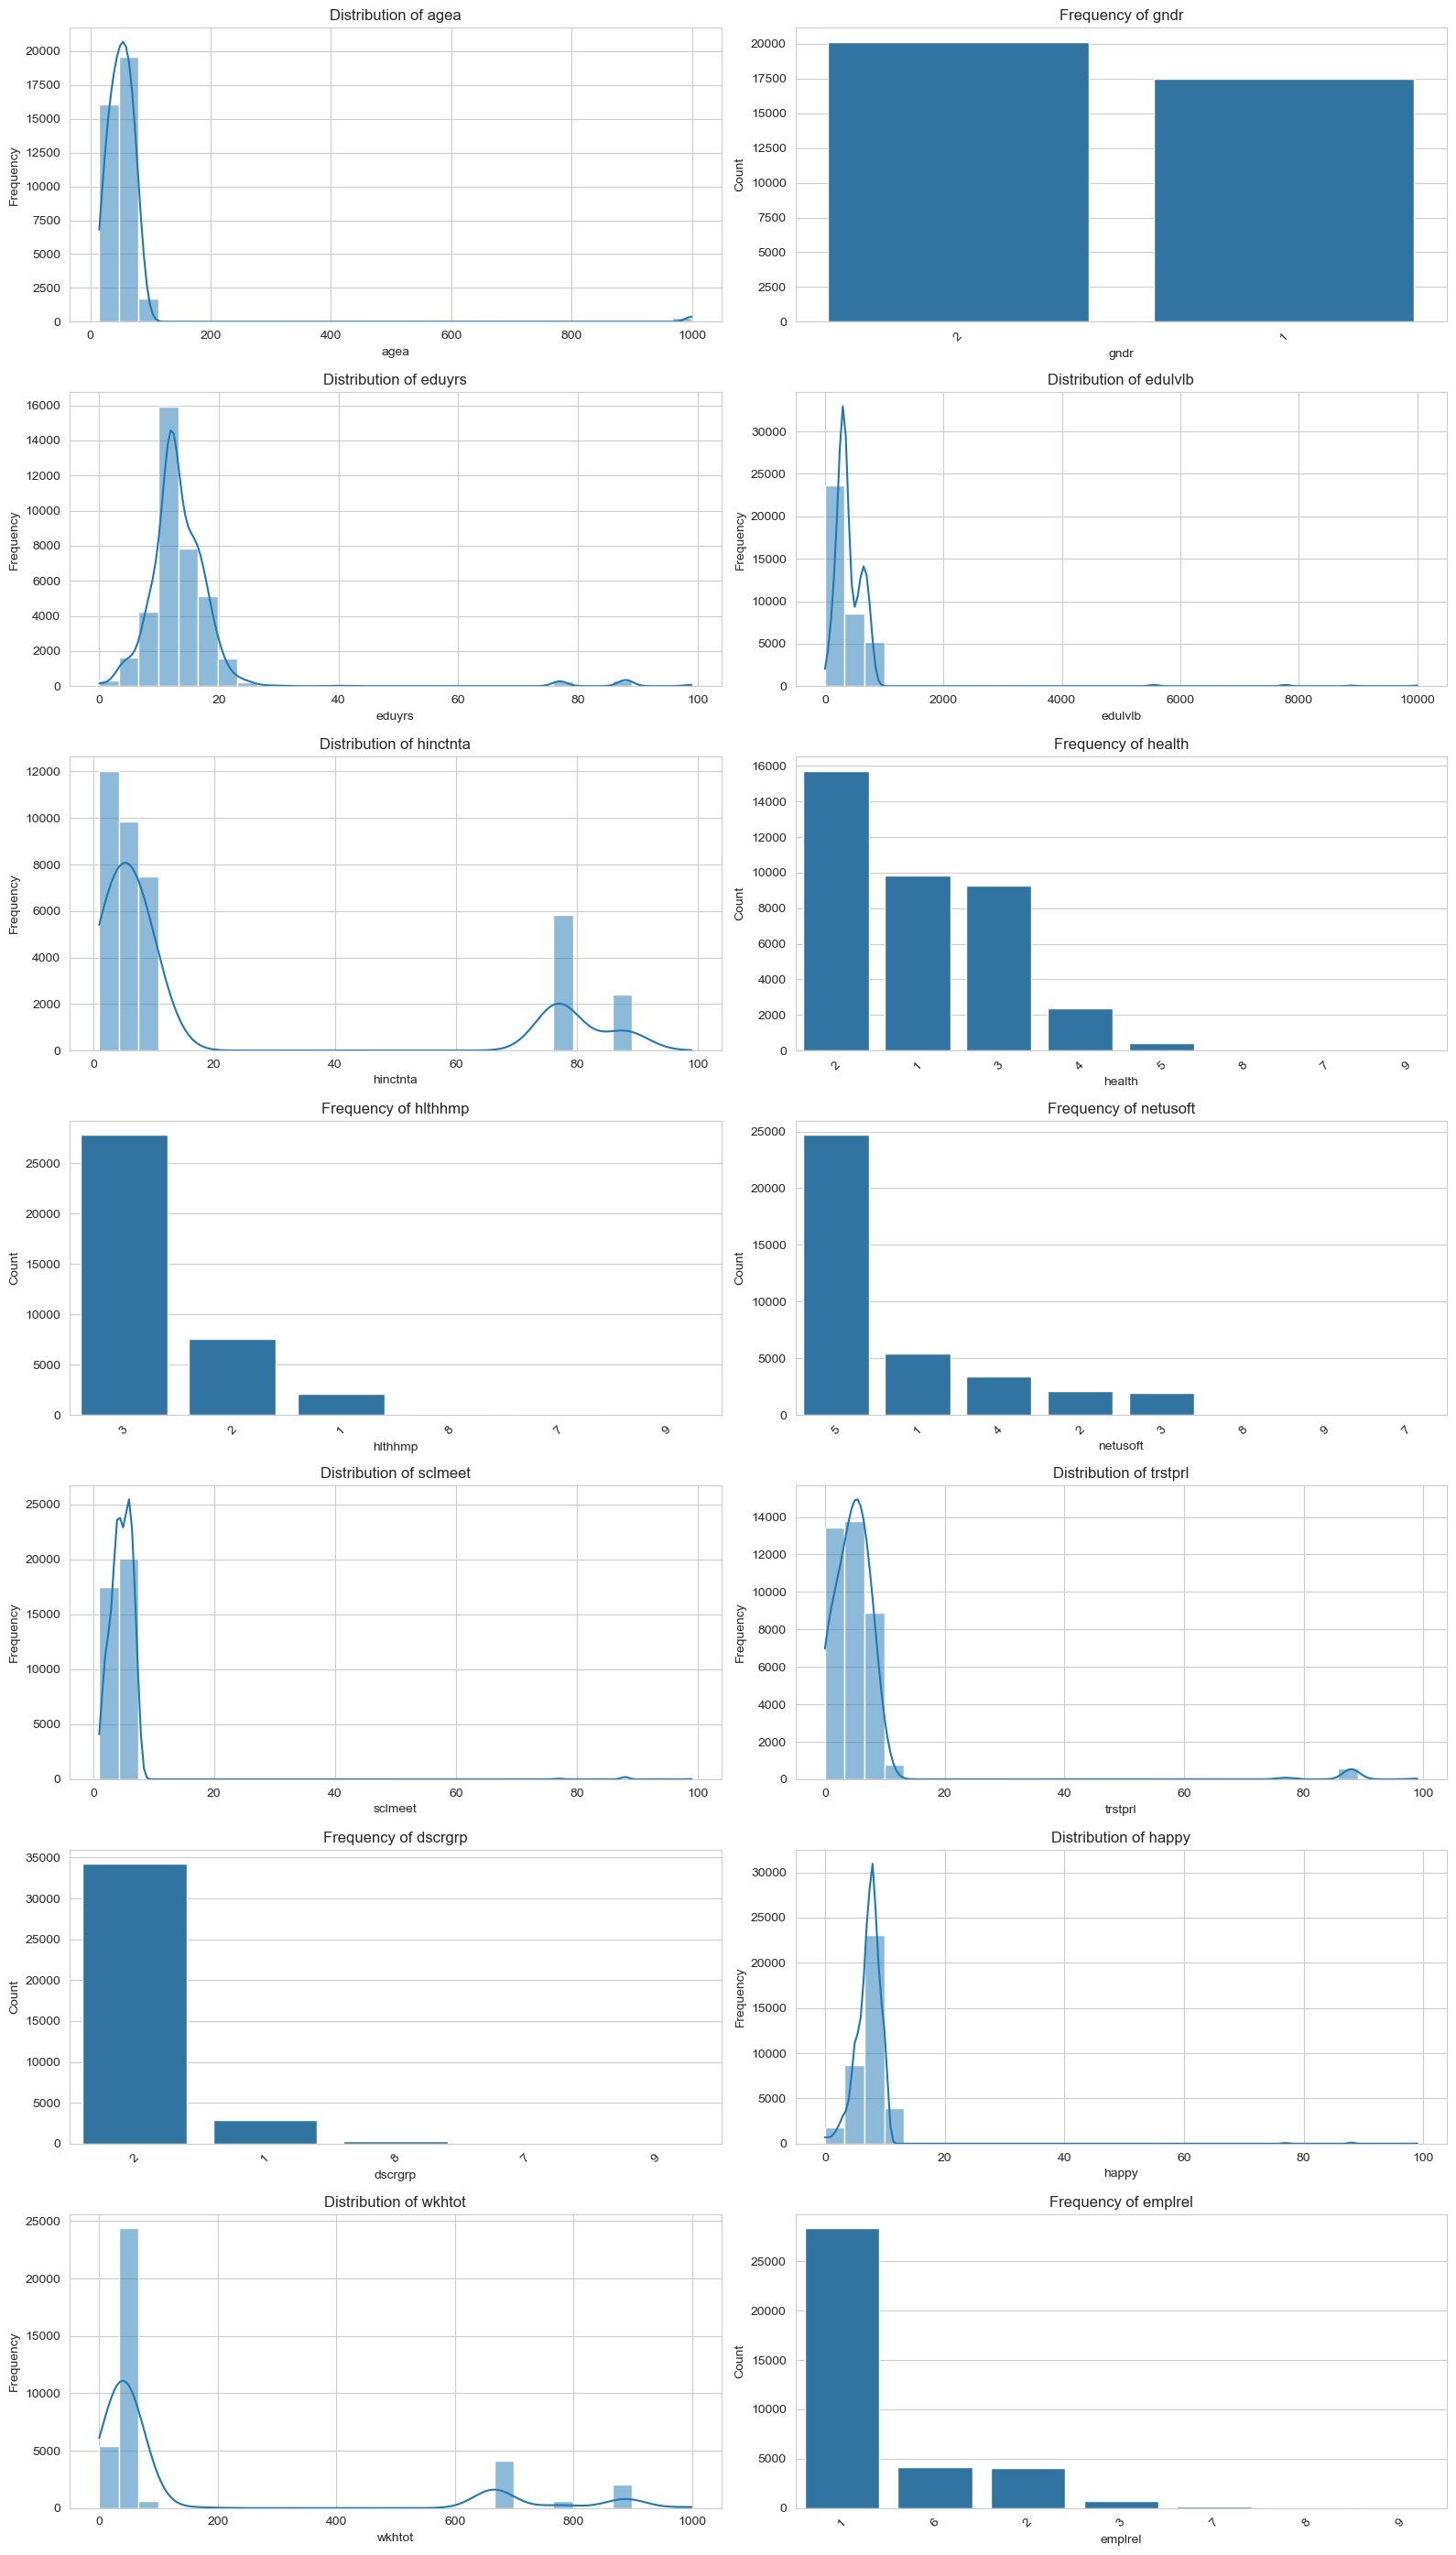

In [29]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Set plot style for better aesthetics
sns.set_style("whitegrid")
%matplotlib inline

# List of selected variables
selected_vars = ['agea', 'gndr', 'eduyrs', 'edulvlb', 'hinctnta', 'health', 'hlthhmp', 
                 'netusoft', 'sclmeet', 'trstprl', 'dscrgrp', 'happy', 'wkhtot', 'emplrel']

# Determine grid dimensions: 2 plots per row
n_vars = len(selected_vars)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()  # Flatten to simplify indexing

# Loop over each variable and assign to a subplot
for i, var in enumerate(selected_vars):
    ax = axes[i]
    
    # Decide what type of plot: categorical or continuous
    if (df[var].dtype == 'object') or (df[var].nunique() < 10):
        # Bar chart for categorical variable
        sns.countplot(data=df, x=var, order=df[var].value_counts().index, ax=ax)
        ax.set_title(f'Frequency of {var}')
        ax.set_ylabel('Count')
        ax.set_xlabel(var)
        ax.tick_params(axis='x', rotation=45)
    else:
        # Histogram with KDE for continuous variable
        sns.histplot(df[var].dropna(), kde=True, bins=30, ax=ax)
        ax.set_title(f'Distribution of {var}')
        ax.set_ylabel('Frequency')
        ax.set_xlabel(var)

# Remove any extra subplots if the number of variables is not even
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<Axes: >

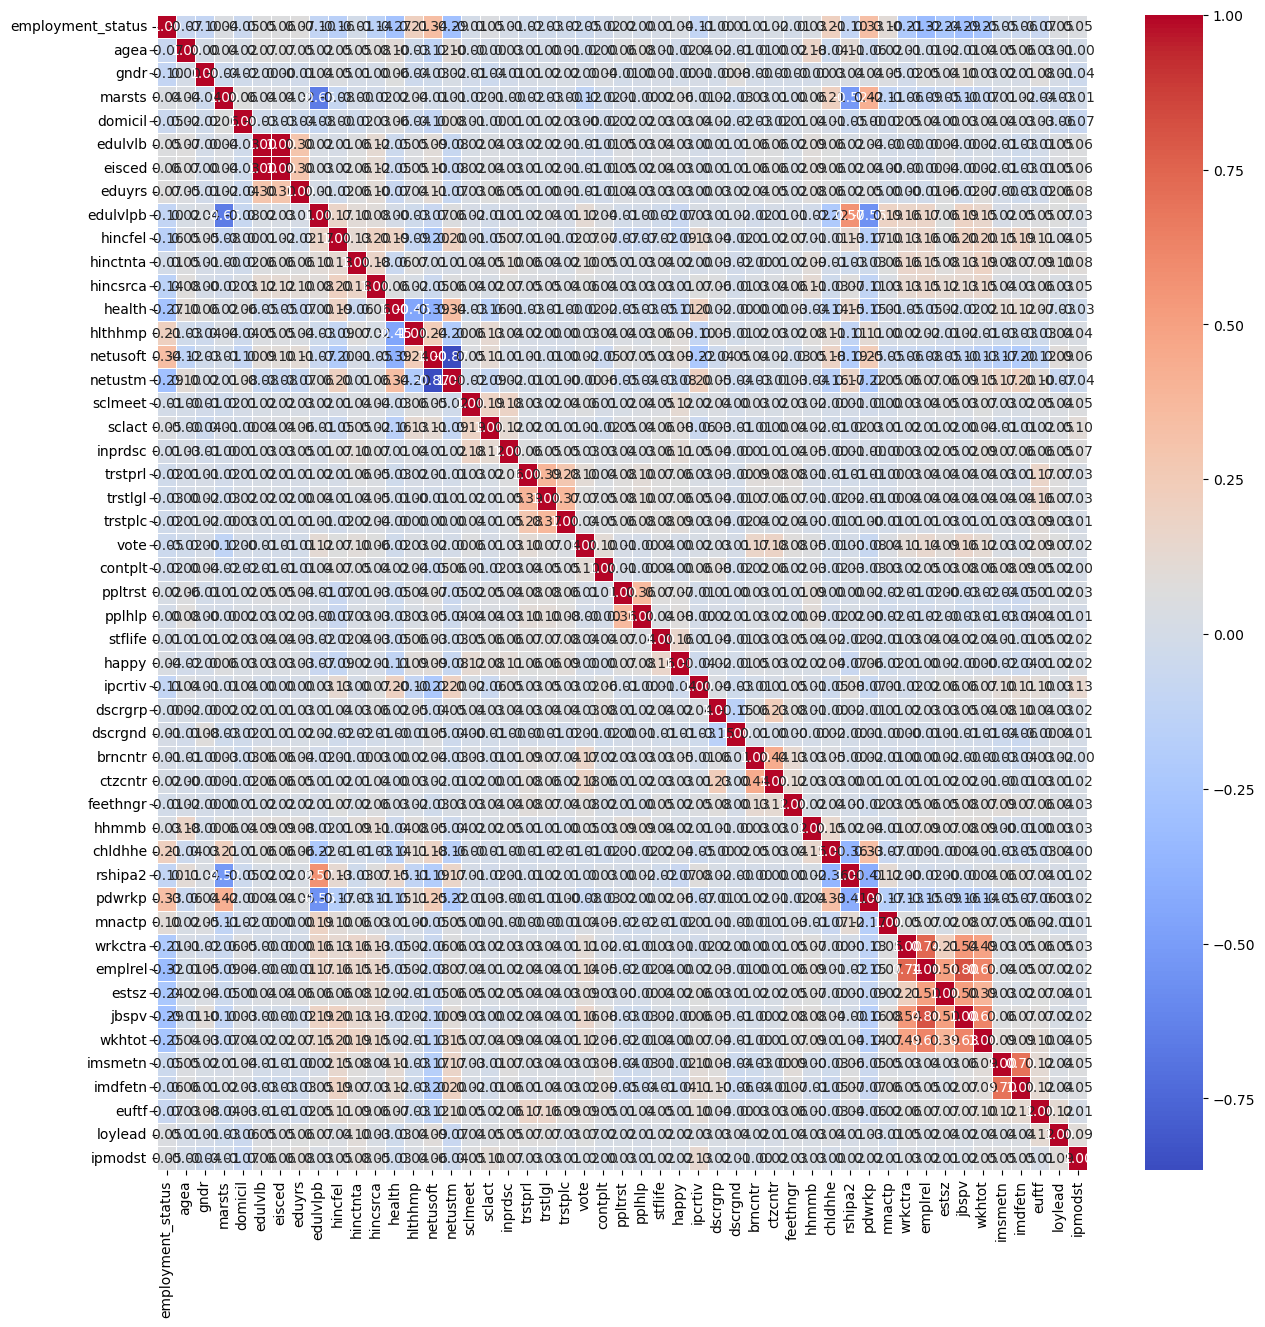

In [366]:
plt.figure(figsize=(15, 15))
sns.heatmap(df_correlations,
            annot=True,
            cmap='coolwarm',
            fmt = '.2f',
            linewidths = 0.5)

In [368]:
mask = np.triu(np.ones_like(df_correlations, dtype = bool))
correlations_with_employment_status = df_correlations.employment_status.sort_values(ascending = False)
ordered_columns = correlations_with_employment_status.index
df_correlations = df_correlations[ordered_columns].loc[ordered_columns]

<Axes: >

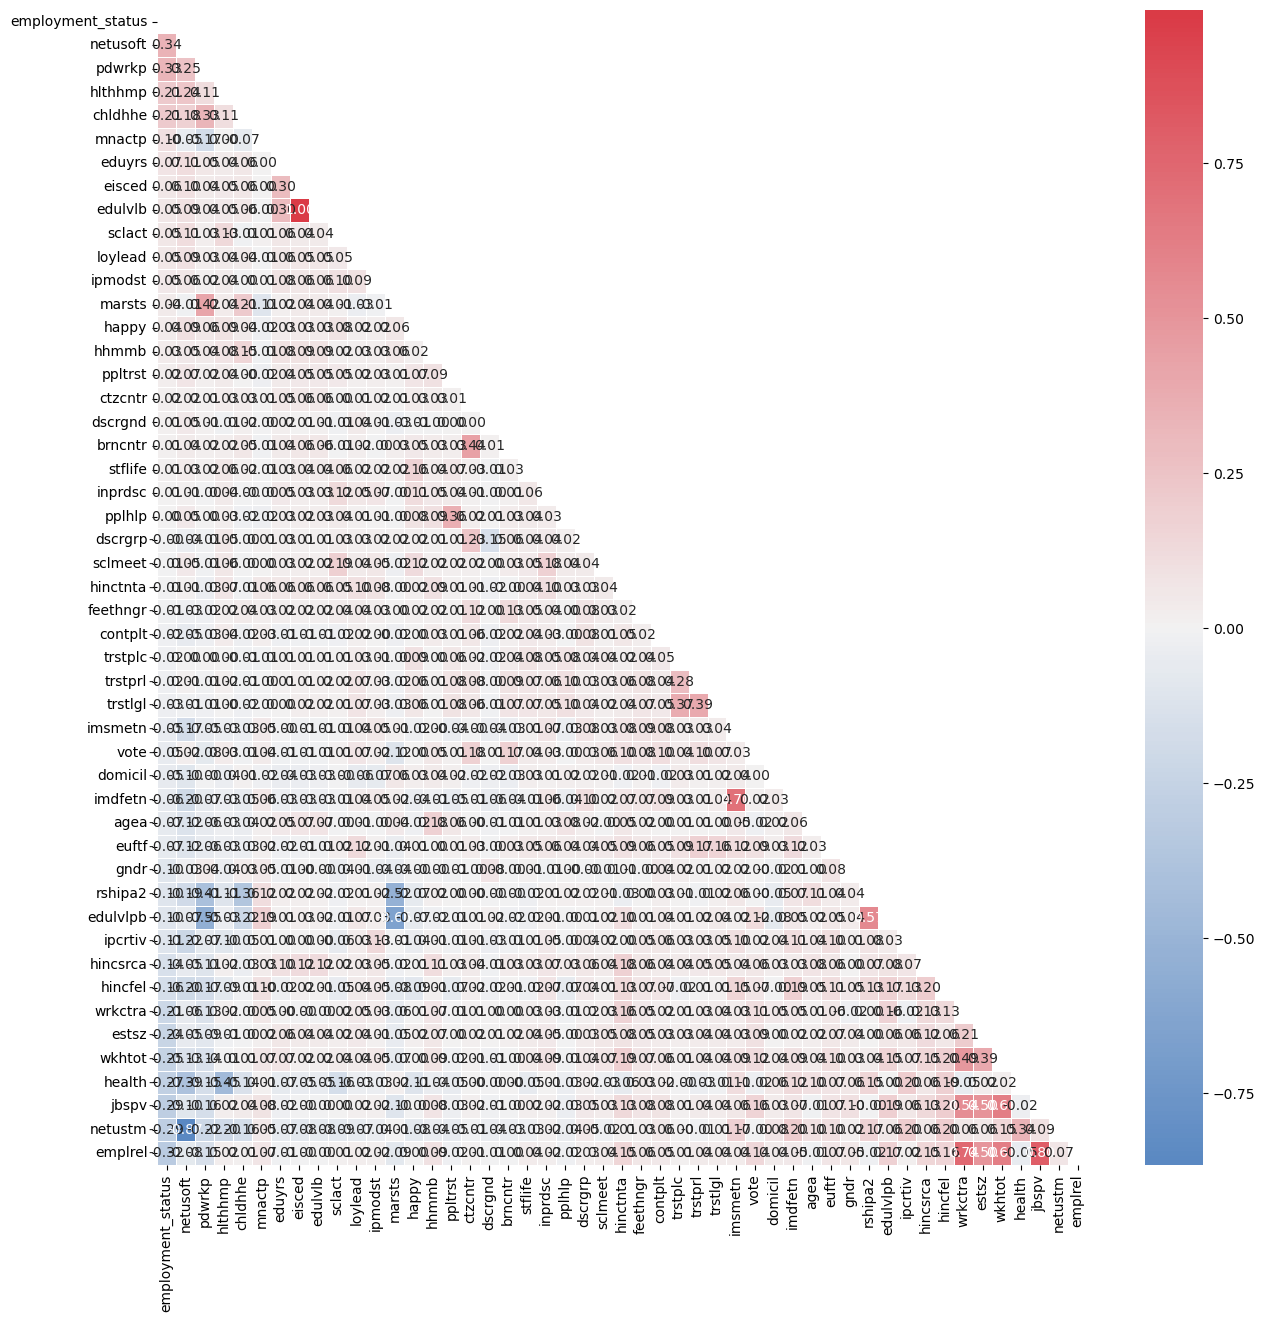

In [370]:
my_cmap = sns.diverging_palette(250, 10, as_cmap = True)
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_correlations,
    annot=True,
    cmap=my_cmap,
    mask = mask,
    fmt = '.2f',
    linewidths = 0.5,
    center = 0
)

<Axes: >

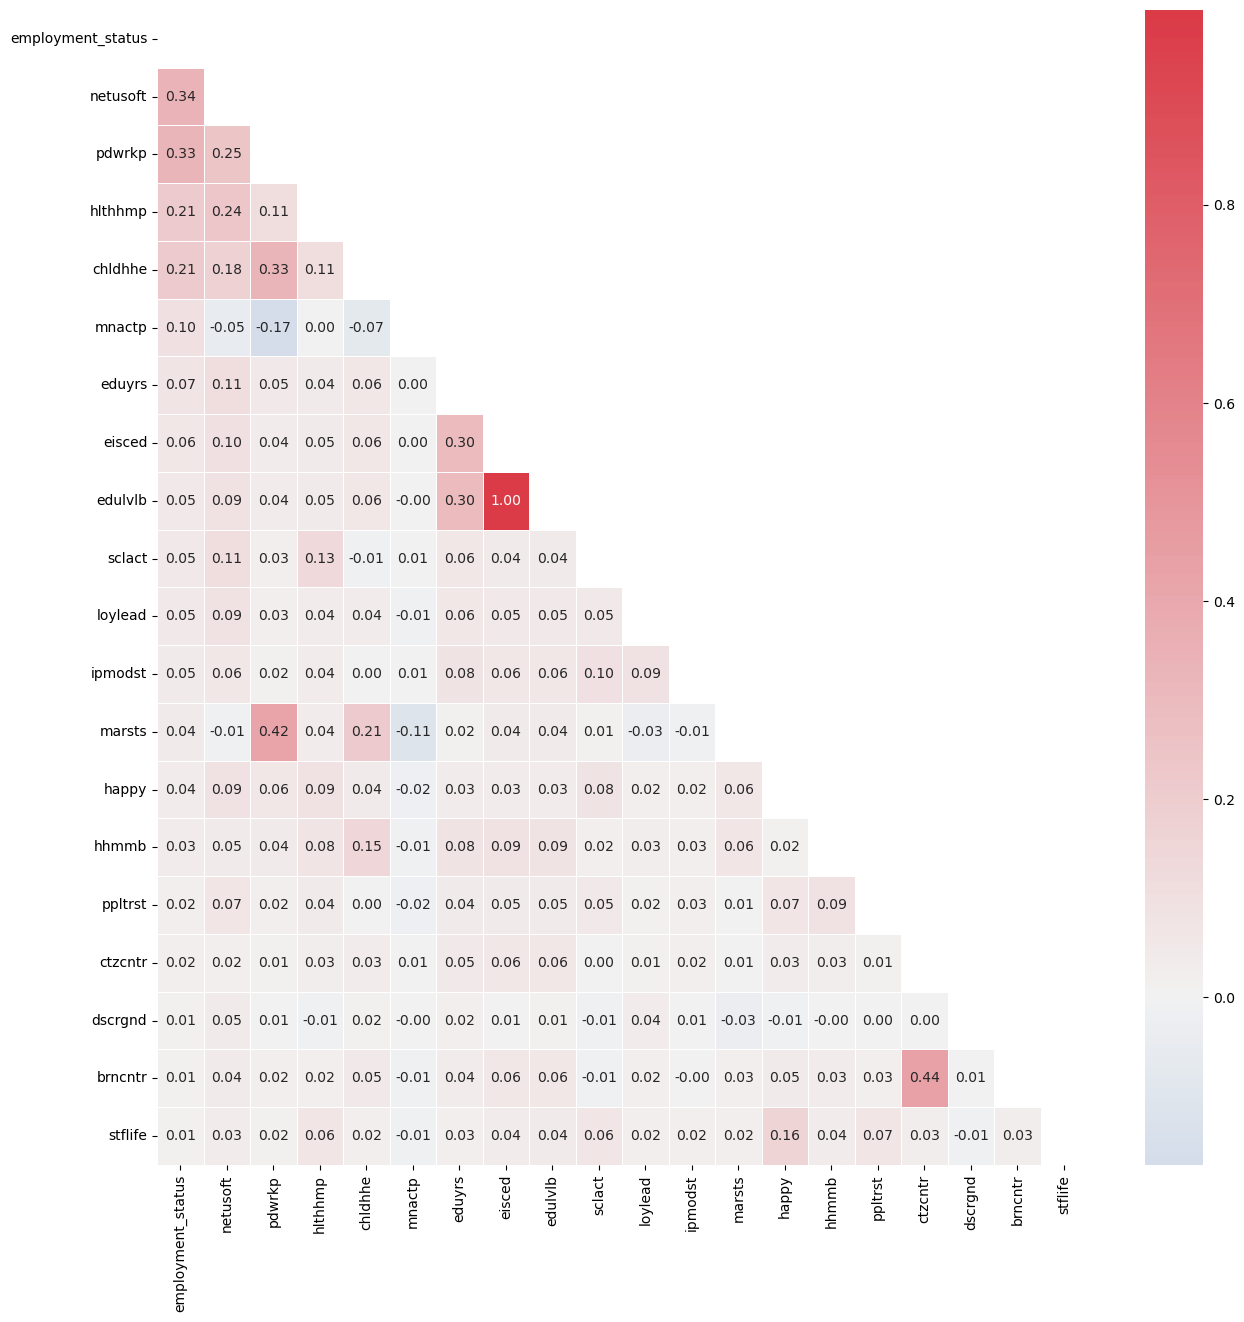

In [372]:
my_cmap = sns.diverging_palette(250, 10, as_cmap = True)
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_correlations.iloc[:20, :20],
    annot=True,
    cmap=my_cmap,
    mask = mask[:20, :20],
    fmt = '.2f',
    linewidths = 0.5,
    center = 0
)

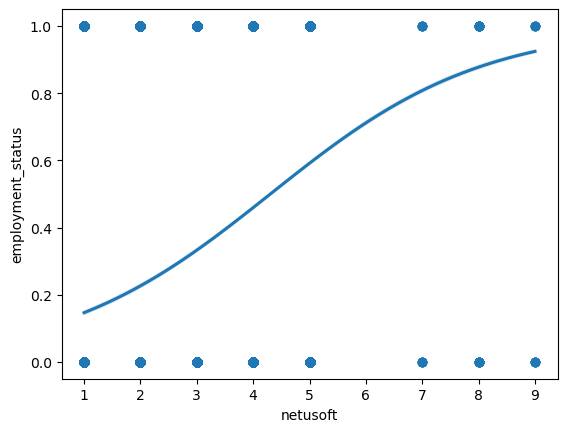

In [374]:
sns.regplot(x=df_train['netusoft'], y=df_train['employment_status'], logistic=True)
plt.show()

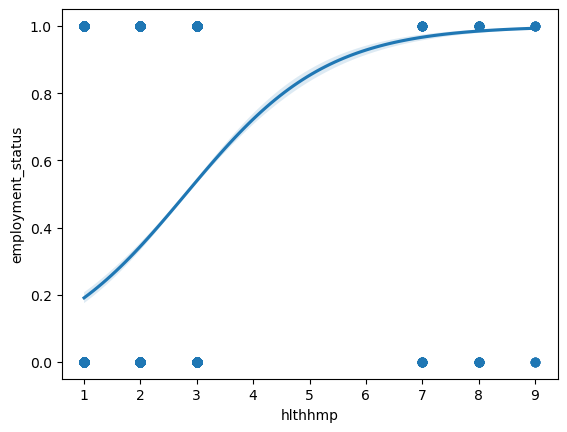

In [376]:
sns.regplot(x=df_train['hlthhmp'], y=df_train['employment_status'], logistic=True)
plt.show()

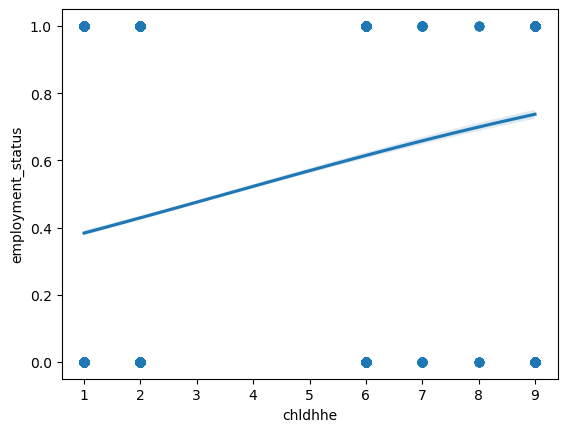

In [378]:
sns.regplot(x=df_train['chldhhe'], y=df_train['employment_status'], logistic=True)
plt.show()

In [380]:
selected_numeric_variables = correlations_with_employment_status.index[1:13].to_list()

In [382]:
selected_numeric_variables

['netusoft',
 'pdwrkp',
 'hlthhmp',
 'chldhhe',
 'mnactp',
 'eduyrs',
 'eisced',
 'edulvlb',
 'sclact',
 'loylead',
 'ipmodst',
 'marsts']

In [384]:
# remove mutually correlated variables - Higher Education vs ES Education
selected_numeric_variables.remove('eisced')

In [215]:
# they are both higher educations, so removing one of them improves the model

In [386]:
selected_numeric_variables

['netusoft',
 'pdwrkp',
 'hlthhmp',
 'chldhhe',
 'mnactp',
 'eduyrs',
 'edulvlb',
 'sclact',
 'loylead',
 'ipmodst',
 'marsts']

In [238]:
# result is, our model is good and no autocorrelation in residuals

In [412]:
model_logit5 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb + sclact + loylead + ipmodst + marsts', 
                        data = df_train).fit()

Optimization terminated successfully.
         Current function value: 0.561408
         Iterations 6


In [414]:
print(model_logit5.summary())

                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30076
Method:                           MLE   Df Model:                           11
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1893
Time:                        20:25:33   Log-Likelihood:                -16892.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.0741      0.120    -50.621      0.000      -6.309      -5.839
netusoft       0.4067      0.011     38.035      0.000       0.386       0.428
pdwrkp         1.4869      0.034     43.712      0.0

In [416]:
dw = durbin_watson(model_logit5.resid_response)
print('Durbin-Watson:', dw)

Durbin-Watson: 2.0092081126763164


- **DW ≈ 2** → no autocorrelation (ideal)  
- **DW near 0** → strong positive autocorrelation (problematic)  
- **DW near 4** → strong negative autocorrelation (also problematic)  

## F-Test for jointly significance

- If this p-value is small (e.g., < 0.05), the variables are jointly significant.

- If not significant, you can proceed with GETS (General-to-Specific modeling), but `statsmodels` doesn’t have automatic GETS—you’ll do it manually by removing variables stepwise.

- If you want an F-test-like test in OLS, that’s different, but logistic models use likelihood-based tests.


In [418]:
print(model_logit5.llr_pvalue)

0.0


- Since p-value is 0.0 (very small), all variables together are significant—GETS (stepwise removal) is optional but can help simplify.  
- If p-value was high, you could remove all insignificant variables at once instead of stepwise.
- If variables are jointly significant (p-value low), you should not remove them all together because they contribute meaningfully as a group.

## GETS

In [319]:
# sclact has the highest p-value so we remove it

In [420]:
# sclact -- removed
model_logit6 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb + loylead + ipmodst + marsts', 
                        data = df_train).fit()

Optimization terminated successfully.
         Current function value: 0.561408
         Iterations 6


In [422]:
print(model_logit6.summary())

                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30077
Method:                           MLE   Df Model:                           10
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1893
Time:                        20:26:16   Log-Likelihood:                -16892.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.0745      0.118    -51.366      0.000      -6.306      -5.843
netusoft       0.4066      0.011     38.129      0.000       0.386       0.428
pdwrkp         1.4869      0.034     43.713      0.0

In [424]:
# edulvlb -- removed
model_logit7 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + loylead + ipmodst + marsts', 
                        data = df_train).fit()

Optimization terminated successfully.
         Current function value: 0.561435
         Iterations 6


In [426]:
print(model_logit7.summary())

                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30078
Method:                           MLE   Df Model:                            9
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1893
Time:                        20:26:29   Log-Likelihood:                -16892.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.0750      0.118    -51.382      0.000      -6.307      -5.843
netusoft       0.4073      0.011     38.226      0.000       0.386       0.428
pdwrkp         1.4862      0.034     43.706      0.0

In [428]:
dw = durbin_watson(model_logit7.resid_response)
print('Durbin-Watson:', dw)

Durbin-Watson: 2.009358692664128


In [430]:
np.exp(model_logit7.params)

Intercept    0.002300
netusoft     1.502702
pdwrkp       4.420447
hlthhmp      1.689497
chldhhe      1.104232
mnactp       1.032619
eduyrs       1.006174
loylead      1.020193
ipmodst      1.043527
marsts       0.992437
dtype: float64

In [438]:
from scipy.stats import chi2
def hosmer_lemeshow(model, data, group=10):
    data = data.copy()
    data['prob'] = model.predict(data)
    data['decile'] = pd.qcut(data['prob'], group, labels=False)
    obs = data.groupby('decile')['employment_status'].sum()
    exp = data.groupby('decile')['prob'].sum()
    n = data.groupby('decile')['employment_status'].count()
    hl_stat = ((obs - exp)**2 / (exp * (1 - exp / n))).sum()
    p_value = 1 - chi2.cdf(hl_stat, group - 2)
    return hl_stat, p_value

In [440]:
hl_stat, p_value = hosmer_lemeshow(model_logit7, df_test)
hl_stat, p_value

(72.2434247847089, 1.7548185127225224e-12)

## Probit

In [442]:
selected_numeric_variables

['netusoft',
 'pdwrkp',
 'hlthhmp',
 'chldhhe',
 'mnactp',
 'eduyrs',
 'edulvlb',
 'sclact',
 'loylead',
 'ipmodst',
 'marsts']

In [448]:
model_probit3 = smf.probit(
    formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb + sclact + loylead + ipmodst + marsts',
    data = df_train
).fit()
print(model_probit3.summary())

Optimization terminated successfully.
         Current function value: 0.561709
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                         Probit   Df Residuals:                    30076
Method:                           MLE   Df Model:                           11
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1889
Time:                        20:27:46   Log-Likelihood:                -16901.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5593      0.067    -53.058      0.000      -3.691      -3.428
netusoft       0.2455      0.

In [450]:
dw = durbin_watson(model_probit3.resid_response)
print('Durbin-Watson:', dw)

Durbin-Watson: 2.0090476914008284


In [452]:
# F - test
print(model_probit3.llr_pvalue)

0.0


In [454]:
model_probit4 = smf.probit(
    formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb + loylead + ipmodst + marsts',
    data = df_train
).fit()
print(model_probit4.summary())

Optimization terminated successfully.
         Current function value: 0.561709
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                         Probit   Df Residuals:                    30077
Method:                           MLE   Df Model:                           10
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1889
Time:                        20:27:55   Log-Likelihood:                -16901.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5580      0.066    -53.919      0.000      -3.687      -3.429
netusoft       0.2455      0.

In [395]:
# loylead p-value was 0.52 before after removing one insignificant variable, it became significant with p-value 0.049

In [456]:
model_probit5 = smf.probit(
    formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + loylead + ipmodst + marsts',
    data = df_train
).fit()
print(model_probit5.summary())

Optimization terminated successfully.
         Current function value: 0.561726
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                         Probit   Df Residuals:                    30078
Method:                           MLE   Df Model:                            9
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1889
Time:                        20:27:58   Log-Likelihood:                -16901.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5595      0.066    -53.947      0.000      -3.689      -3.430
netusoft       0.2458      0.

---
model_logit5 - General \
model_logit7 - GETS

model_probit3 - General \
model_probit5 - GETS

---

In [458]:
print(f'Logit Specified Model --- AIC: {model_logit7.aic} BIC: {model_logit7.bic}')

Logit Specified Model --- AIC: 33804.89600654028 BIC: 33888.01482354178


In [460]:
print(f'Probit Specified Model --- AIC: {model_probit5.aic} BIC: {model_probit5.bic}')

Probit Specified Model --- AIC: 33822.422370026354 BIC: 33905.541187027855


In [462]:
hl_stat, p_value = hosmer_lemeshow(model_probit5, df_test)
hl_stat, p_value

(68.27282510973296, 1.0837775121785853e-11)

In [464]:
odds_ratios = np.exp(model_logit7.params)
print(odds_ratios)

Intercept    0.002300
netusoft     1.502702
pdwrkp       4.420447
hlthhmp      1.689497
chldhhe      1.104232
mnactp       1.032619
eduyrs       1.006174
loylead      1.020193
ipmodst      1.043527
marsts       0.992437
dtype: float64


In [466]:
# link test
df_train['hat'] = model_logit7.fittedvalues
df_train['hatsq'] = df_train['hat']**2

linktest_model = sm.Logit(df_train['employment_status'], sm.add_constant(df_train[['hat', 'hatsq']])).fit()
print(linktest_model.summary())

Optimization terminated successfully.
         Current function value: 0.558111
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30085
Method:                           MLE   Df Model:                            2
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.1941
Time:                        20:28:15   Log-Likelihood:                -16792.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1304      0.016      8.138      0.000       0.099       0.162
hat            0.9829      0.

In [472]:
predicted = (model_logit7.predict() > 0.5).astype(int)
actual = df_train['employment_status']
count_r2 = (predicted == actual).mean()
print("Count R2:", count_r2)

Count R2: 0.7075245945227333


In [474]:
n = len(df_train)
k = 9 # e.g., 9 in your model_logit7
count_r2 = 0.7075

adj_count_r2 = 1 - ((n - 1) / (n - k - 1)) * (1 - count_r2)
adj_count_r2

0.7074124775583484

In [438]:
# Adjusted R2 shows that: it is similar to Count R2. meaning model is not overfitting

Adjusted Count R²
Will be slightly lower than 0.7075, reflecting penalty for complexity.

If close to Count R², it means your model isn’t overfitting much.

Now saw that all tests which i did shows good results except link test , thats why i will try to add from correlation heatmap negative effect columns too, and rerun the models  one more time .

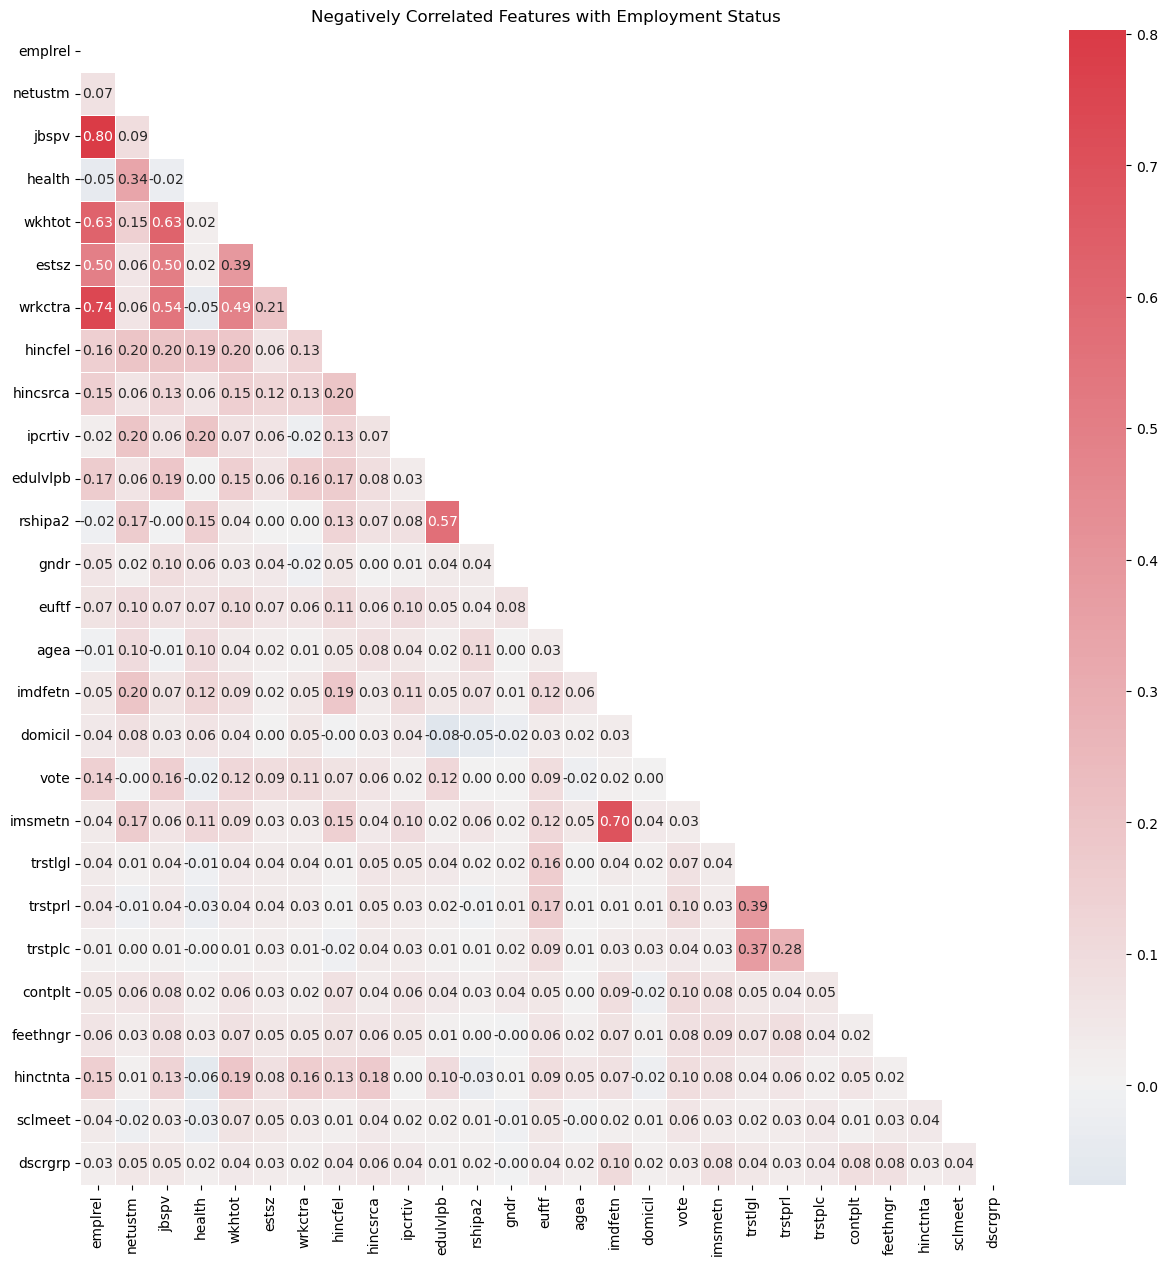

In [205]:
# Get only negatively correlated columns
correlations_with_employment_status = df_correlations['employment_status'].sort_values()
negative_corr_columns = correlations_with_employment_status[correlations_with_employment_status < 0].index

# Filter correlation matrix
df_negative_corr = df_correlations.loc[negative_corr_columns, negative_corr_columns]

# Create mask
mask_neg = np.triu(np.ones_like(df_negative_corr, dtype=bool))

# Plot heatmap
my_cmap = sns.diverging_palette(250, 10, as_cmap=True)
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_negative_corr,
    annot=True,
    cmap=my_cmap,
    mask=mask_neg,
    fmt='.2f',
    linewidths=0.5,
    center=0
)
plt.title("Negatively Correlated Features with Employment Status")
plt.show()


In [476]:
print(df_negative_corr.columns)

Index(['emplrel', 'netustm', 'jbspv', 'health', 'wkhtot', 'estsz', 'wrkctra',
       'hincfel', 'hincsrca', 'ipcrtiv', 'edulvlpb', 'rshipa2', 'gndr',
       'euftf', 'agea', 'imdfetn', 'domicil', 'vote', 'imsmetn', 'trstlgl',
       'trstprl', 'trstplc', 'contplt', 'feethngr', 'hinctnta', 'sclmeet',
       'dscrgrp'],
      dtype='object')


In [227]:
model_logit8 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb + sclact + loylead + ipmodst + marsts + emplrel', 
                        data = df_train).fit()

Optimization terminated successfully.
         Current function value: 0.499759
         Iterations 7


In [229]:
print(model_logit8.summary())

                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30075
Method:                           MLE   Df Model:                           12
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.2784
Time:                        19:46:53   Log-Likelihood:                -15037.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.9736      0.126    -47.594      0.000      -6.220      -5.728
netusoft       0.4184      0.011     37.357      0.000       0.396       0.440
pdwrkp         1.4092      0.036     38.857      0.0

In [223]:
model_logit9 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb + sclact + loylead + ipmodst + marsts + emplrel + netustm + jbspv + health + wkhtot', 
                        data = df_train).fit()

Optimization terminated successfully.
         Current function value: 0.489030
         Iterations 7


In [225]:
print(model_logit9.summary())

                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30071
Method:                           MLE   Df Model:                           16
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.2938
Time:                        19:46:47   Log-Likelihood:                -14714.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.4968      0.174    -25.839      0.000      -4.838      -4.156
netusoft       0.4439      0.021     20.935      0.000       0.402       0.485
pdwrkp         1.3575      0.037     37.023      0.0

#GETS

CHeking autocorrelation test

In [232]:
dw = durbin_watson(model_logit9.resid_response)
print('Durbin-Watson:', dw)

Durbin-Watson: 2.009694529692852


F-test

In [234]:
print(model_logit5.llr_pvalue)

0.0


In [238]:
model_logit10 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + edulvlb +  loylead + ipmodst + marsts + emplrel + netustm + jbspv + health + wkhtot', 
                        data = df_train).fit()
print(model_logit10.summary())

Optimization terminated successfully.
         Current function value: 0.489036
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30072
Method:                           MLE   Df Model:                           15
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.2938
Time:                        19:52:52   Log-Likelihood:                -14714.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.5149      0.172    -26.294      0.000      -4.851      -4.178
netusoft       0.4433      0.

In [240]:
model_logit11 = smf.logit(formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs +  loylead + ipmodst + marsts + emplrel + netustm + jbspv + health + wkhtot', 
                        data = df_train).fit()
print(model_logit11.summary())

Optimization terminated successfully.
         Current function value: 0.489060
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30073
Method:                           MLE   Df Model:                           14
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.2938
Time:                        19:55:22   Log-Likelihood:                -14715.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.5111      0.172    -26.262      0.000      -4.848      -4.174
netusoft       0.4439      0.

In [244]:
model_probit6 = smf.probit(
    formula = 'employment_status ~ netusoft + pdwrkp + hlthhmp + chldhhe + mnactp + eduyrs + loylead + ipmodst + marsts + emplrel + netustm + jbspv + health + wkhtot',
    data = df_train
).fit()
print(model_probit6.summary())

Optimization terminated successfully.
         Current function value: 0.490121
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                         Probit   Df Residuals:                    30073
Method:                           MLE   Df Model:                           14
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.2923
Time:                        19:58:57   Log-Likelihood:                -14747.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.5863      0.097    -26.616      0.000      -2.777      -2.396
netusoft       0.2599      0.

In [246]:
print(model_probit6.llr_pvalue)

0.0


In [248]:
print(f'Logit Specified Model --- AIC: {model_logit11.aic} BIC: {model_logit11.bic}')

Logit Specified Model --- AIC: 29459.646264135623 BIC: 29584.324489637875


In [250]:
print(f'Logit Specified Model --- AIC: {model_probit6.aic} BIC: {model_probit6.bic}')

Logit Specified Model --- AIC: 29523.543274415522 BIC: 29648.221499917774


In [258]:
hl_stat, p_value = hosmer_lemeshow(model_logit11, df_test)
hl_stat, p_value

(141.5157392604569, 0.0)

In [260]:
odds_ratios = np.exp(model_logit11.params)
print(odds_ratios)

Intercept    0.010987
netusoft     1.558711
pdwrkp       3.885909
hlthhmp      1.525511
chldhhe      1.148309
mnactp       1.038677
eduyrs       1.005660
loylead      1.043959
ipmodst      1.069836
marsts       0.991051
emplrel      0.576546
netustm      1.000054
jbspv        0.882709
health       0.655688
wkhtot       0.999649
dtype: float64


In [262]:
# link test
df_train['hat'] = model_logit11.fittedvalues
df_train['hatsq'] = df_train['hat']**2

linktest_model = sm.Logit(df_train['employment_status'], sm.add_constant(df_train[['hat', 'hatsq']])).fit()
print(linktest_model.summary())

Optimization terminated successfully.
         Current function value: 0.485425
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      employment_status   No. Observations:                30088
Model:                          Logit   Df Residuals:                    30085
Method:                           MLE   Df Model:                            2
Date:                Sun, 25 May 2025   Pseudo R-squ.:                  0.2991
Time:                        20:02:47   Log-Likelihood:                -14605.
converged:                       True   LL-Null:                       -20837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1565      0.018      8.725      0.000       0.121       0.192
hat            0.9901      0.

In [264]:
predicted = (model_logit11.predict() > 0.5).astype(int)
actual = df_train['employment_status']
count_r2 = (predicted == actual).mean()
print("Count R2:", count_r2)

Count R2: 0.7688779579898963


In [268]:
n = len(df_train)
k = 14 # e.g., 9 in your model_logit7
count_r2 = 0.7688

adj_count_r2 = 1 - ((n - 1) / (n - k - 1)) * (1 - count_r2)
adj_count_r2

0.7686923685698135